<a href="https://colab.research.google.com/github/Ganasa18/belajar-tensorflow/blob/main/train_class_prompt_labeling_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================================================
# CELL 1 — GOOGLE DRIVE + PATH SETUP
# AGENT ROUTER V1
# =========================================================

from google.colab import drive

import os


# =========================================================
# MOUNT DRIVE
# =========================================================

DRIVE_MOUNT = "/content/drive"

drive.mount(
    DRIVE_MOUNT,
    force_remount=False
)

assert os.path.exists(
    f"{DRIVE_MOUNT}/MyDrive"
), "Google Drive belum mounted."


# =========================================================
# STORAGE
# =========================================================

SAVE_DIR = (
    f"{DRIVE_MOUNT}/MyDrive/router_classifier"
)

AGENT_DIR = (
    f"{SAVE_DIR}/agent_router_v1"
)

os.makedirs(
    AGENT_DIR,
    exist_ok=True
)


# =========================================================
# PATHS
# =========================================================

AGENT_DATASET_PATH = (
    f"{AGENT_DIR}/agent_router_v1_dataset.csv"
)

AGENT_AUDIT_PATH = (
    f"{AGENT_DIR}/agent_router_v1_audit.csv"
)

AGENT_MODEL_PATH = (
    f"{AGENT_DIR}/agent_router_v1.joblib"
)

AGENT_ONNX_PATH = (
    f"{AGENT_DIR}/agent_router_v1.onnx"
)

AGENT_METRICS_PATH = (
    f"{AGENT_DIR}/agent_router_v1_metrics.json"
)


print()
print("=" * 70)
print("AGENT ROUTER V1 — STORAGE")
print("=" * 70)

print("Directory :", AGENT_DIR)
print("Dataset   :", AGENT_DATASET_PATH)
print("Model     :", AGENT_MODEL_PATH)
print("ONNX      :", AGENT_ONNX_PATH)

print("=" * 70)

Mounted at /content/drive

AGENT ROUTER V1 — STORAGE
Directory : /content/drive/MyDrive/router_classifier/agent_router_v1
Dataset   : /content/drive/MyDrive/router_classifier/agent_router_v1/agent_router_v1_dataset.csv
Model     : /content/drive/MyDrive/router_classifier/agent_router_v1/agent_router_v1.joblib
ONNX      : /content/drive/MyDrive/router_classifier/agent_router_v1/agent_router_v1.onnx


In [2]:
# =========================================================
# CELL 2 — AGENT ROUTING TAXONOMY
# AGENT ROUTER V1
# =========================================================

AGENT_LABELS = [
    "DIRECT",
    "WEB_SEARCH",
    "TOOL_SINGLE",
    "TOOL_MULTI_STEP",
]


AGENT_DESCRIPTIONS = {

    "DIRECT":
        "The request can be answered directly using existing "
        "knowledge or local reasoning without needing current "
        "web information or an external action.",

    "WEB_SEARCH":
        "The request primarily requires retrieving fresh, current, "
        "external, public, or online information. Web retrieval is "
        "needed, but the task does not require executing another "
        "external application action.",

    "TOOL_SINGLE":
        "The request requires one primary external tool or application "
        "action, such as reading email, creating a calendar event, "
        "writing to a spreadsheet, reading a file, or controlling a device.",

    "TOOL_MULTI_STEP":
        "The request requires multiple dependent external actions, "
        "especially workflows such as search -> filter -> compare -> "
        "write, read -> summarize -> send, or inspect -> decide -> execute.",
}


# =========================================================
# VALIDATION
# =========================================================

assert len(AGENT_LABELS) == 4

for label in AGENT_LABELS:

    if label not in AGENT_DESCRIPTIONS:

        raise ValueError(
            f"Missing description: {label}"
        )


print()
print("=" * 70)
print("AGENT ROUTER TAXONOMY")
print("=" * 70)

for i, label in enumerate(
    AGENT_LABELS,
    start=1
):

    print(
        f"{i}. {label}"
    )

print()
print(
    "Total:",
    len(AGENT_LABELS)
)

print("=" * 70)


AGENT ROUTER TAXONOMY
1. DIRECT
2. WEB_SEARCH
3. TOOL_SINGLE
4. TOOL_MULTI_STEP

Total: 4


In [3]:
# =========================================================
# CELL 3 — TAXONOMY SANITY EXAMPLES
# AGENT ROUTER V1
# =========================================================

AGENT_EXAMPLES = [

    # DIRECT
    (
        "jelaskan fungsi ESP32 C6",
        "DIRECT"
    ),

    (
        "buat cerita tentang robot kecil",
        "DIRECT"
    ),

    (
        "bandingkan UART dan SPI secara konsep",
        "DIRECT"
    ),

    # WEB SEARCH
    (
        "berapa harga emas hari ini",
        "WEB_SEARCH"
    ),

    (
        "cari harga ESP32 terbaru di Indonesia",
        "WEB_SEARCH"
    ),

    (
        "siapa CEO perusahaan itu sekarang",
        "WEB_SEARCH"
    ),

    # TOOL SINGLE
    (
        "masukkan data ini ke Google Sheet",
        "TOOL_SINGLE"
    ),

    (
        "cek email terakhir dari Andi",
        "TOOL_SINGLE"
    ),

    (
        "buat meeting besok jam 10",
        "TOOL_SINGLE"
    ),

    # TOOL MULTI STEP
    (
        "cari 10 ESP32 termurah di marketplace Indonesia "
        "lalu masukkan hasilnya ke Google Sheet",
        "TOOL_MULTI_STEP"
    ),

    (
        "cek email yang belum dibaca, rangkum yang penting, "
        "lalu kirim hasilnya ke Slack",
        "TOOL_MULTI_STEP"
    ),

    (
        "cari jadwal kosong saya lalu buat meeting dengan Budi",
        "TOOL_MULTI_STEP"
    ),
]


print()
print("=" * 70)
print("AGENT ROUTER EXAMPLES")
print("=" * 70)

for text, label in AGENT_EXAMPLES:

    print(
        f"{label:16} | {text}"
    )

print("=" * 70)


AGENT ROUTER EXAMPLES
DIRECT           | jelaskan fungsi ESP32 C6
DIRECT           | buat cerita tentang robot kecil
DIRECT           | bandingkan UART dan SPI secara konsep
WEB_SEARCH       | berapa harga emas hari ini
WEB_SEARCH       | cari harga ESP32 terbaru di Indonesia
WEB_SEARCH       | siapa CEO perusahaan itu sekarang
TOOL_SINGLE      | masukkan data ini ke Google Sheet
TOOL_SINGLE      | cek email terakhir dari Andi
TOOL_SINGLE      | buat meeting besok jam 10
TOOL_MULTI_STEP  | cari 10 ESP32 termurah di marketplace Indonesia lalu masukkan hasilnya ke Google Sheet
TOOL_MULTI_STEP  | cek email yang belum dibaca, rangkum yang penting, lalu kirim hasilnya ke Slack
TOOL_MULTI_STEP  | cari jadwal kosong saya lalu buat meeting dengan Budi


In [7]:
# =========================================================
# CELL 4 — TEACHER API SETUP
# AGENT ROUTER V1
# =========================================================

import requests
import json
import re
import time

from google.colab import userdata


# =========================================================
# API CONFIG
# =========================================================

BASE_URL = (
    "https://api.deepseek.com/chat/completions"
)

API_KEY = userdata.get(
    "DEEPSEEK"
)

MODEL = "deepseek-v4-flash"

TIMEOUT_CONNECT = 10
TIMEOUT_READ = 45


if not API_KEY:

    raise RuntimeError(
        "DEEPSEEK API key tidak ditemukan "
        "di Colab Secrets."
    )


# =========================================================
# TEACHER PROMPT
# =========================================================

AGENT_TEACHER_PROMPT = """
You are a strict execution-routing classifier.

Your task is NOT to answer the user's request.

Determine how the request should be executed.

Choose exactly ONE label:

DIRECT
WEB_SEARCH
TOOL_SINGLE
TOOL_MULTI_STEP

=========================================================
DIRECT
=========================================================

Use DIRECT when the request can be completed using
existing knowledge, reasoning, generation, coding,
translation, summarization, or other local processing.

No fresh online information or external application action
is required.

Examples:

"jelaskan cara kerja DNS"
-> DIRECT

"buat regex validasi email"
-> DIRECT

"buat cerita tentang robot"
-> DIRECT

"bandingkan ESP32 C5 dan C6 berdasarkan spesifikasi yang
sudah diberikan"
-> DIRECT

=========================================================
WEB_SEARCH
=========================================================

Use WEB_SEARCH when current or external public information
must be retrieved from the internet.

Examples:

"berapa harga emas hari ini"
-> WEB_SEARCH

"cari harga ESP32 terbaru"
-> WEB_SEARCH

"apa berita AI terbaru hari ini"
-> WEB_SEARCH

Important:

A web search that only retrieves information remains
WEB_SEARCH.

=========================================================
TOOL_SINGLE
=========================================================

Use TOOL_SINGLE when the request requires one primary
external application or device action.

Examples:

"cek email terakhir saya"
-> TOOL_SINGLE

"masukkan data ini ke Google Sheet"
-> TOOL_SINGLE

"buat event kalender besok jam 10"
-> TOOL_SINGLE

"baca file report.pdf saya"
-> TOOL_SINGLE

=========================================================
TOOL_MULTI_STEP
=========================================================

Use TOOL_MULTI_STEP when the request requires multiple
dependent tool actions or an agent workflow.

Typical patterns:

search -> compare -> write
read -> analyze -> send
find -> choose -> create
inspect -> decide -> execute

Examples:

"cari 10 ESP32 termurah lalu masukkan ke Google Sheet"
-> TOOL_MULTI_STEP

"cek email belum dibaca, rangkum, lalu kirim hasilnya ke Slack"
-> TOOL_MULTI_STEP

"cari waktu kosong saya lalu buat meeting dengan Andi"
-> TOOL_MULTI_STEP

=========================================================
IMPORTANT BOUNDARIES
=========================================================

"berapa harga emas hari ini"
-> WEB_SEARCH

"cari harga emas lalu masukkan ke spreadsheet"
-> TOOL_MULTI_STEP


"jelaskan isi email berikut: [content provided]"
-> DIRECT

"baca email saya dan jelaskan isinya"
-> TOOL_SINGLE


"ringkas teks berikut"
-> DIRECT

"baca file saya lalu ringkas"
-> TOOL_SINGLE


"buat query SQL"
-> DIRECT

"jalankan query SQL pada database saya"
-> TOOL_SINGLE


=========================================================
OUTPUT
=========================================================

Return ONLY valid JSON:

{
  "label": "LABEL",
  "confidence": 0.95
}

confidence must be between 0 and 1.
"""


# =========================================================
# CALL
# =========================================================

def call_agent_teacher(prompt):

    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json",
    }

    payload = {
        "model": MODEL,
        "temperature": 0,

        "thinking": {
            "type": "disabled"
        },

        "response_format": {
            "type": "json_object"
        },

        "messages": [
            {
                "role": "system",
                "content": AGENT_TEACHER_PROMPT,
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
    }

    start = time.time()

    response = requests.post(
        BASE_URL,
        headers=headers,
        json=payload,
        timeout=(
            TIMEOUT_CONNECT,
            TIMEOUT_READ
        ),
    )

    response.raise_for_status()

    latency = (
        time.time()
        - start
    )

    content = (
        response
        .json()["choices"][0]["message"]["content"]
    )

    return content, latency


# =========================================================
# PARSER
# =========================================================

def parse_agent_teacher(text):

    if not text:

        raise ValueError(
            "Teacher response kosong."
        )

    text = text.strip()

    text = re.sub(
        r"^```(?:json)?\s*",
        "",
        text,
        flags=re.I
    )

    text = re.sub(
        r"\s*```$",
        "",
        text
    )

    match = re.search(
        r"\{[\s\S]*?\}",
        text
    )

    if not match:

        raise ValueError(
            "JSON tidak ditemukan."
        )

    data = json.loads(
        match.group()
    )

    label = str(
        data.get("label", "")
    ).strip().upper()

    confidence = float(
        data.get("confidence")
    )


    if label not in AGENT_LABELS:

        raise ValueError(
            f"Invalid label: {label}"
        )

    if not 0 <= confidence <= 1:

        raise ValueError(
            f"Invalid confidence: {confidence}"
        )


    return {
        "label": label,
        "confidence": confidence,
    }


print()
print("=" * 70)
print("AGENT TEACHER SETUP")
print("=" * 70)

print("Model   :", MODEL)
print("API key : OK")
print("Labels  :", len(AGENT_LABELS))

print("=" * 70)


AGENT TEACHER SETUP
Model   : deepseek-v4-flash
API key : OK
Labels  : 4


In [8]:
# =========================================================
# CELL 5 — GENERATE AGENT ROUTER DATASET
# AGENT ROUTER V1
# =========================================================

import json
import requests
import pandas as pd
import time


TARGET_PER_LABEL = {
    "DIRECT": 80,
    "WEB_SEARCH": 80,
    "TOOL_SINGLE": 80,
    "TOOL_MULTI_STEP": 80,
}


GENERATOR_PROMPT = """
You generate training examples for an execution-routing classifier.

Generate realistic USER REQUESTS only.
Do NOT answer the request.

The target labels are:

DIRECT
WEB_SEARCH
TOOL_SINGLE
TOOL_MULTI_STEP

Use both Indonesian and English.

Make requests diverse:
- short
- long
- casual
- typo-like
- technical
- everyday assistant requests

Avoid duplicates and near duplicates.

Important boundaries:

DIRECT:
Can be answered locally without fresh web information
or external application actions.

WEB_SEARCH:
Needs current or external public online information,
but only retrieval is required.

TOOL_SINGLE:
Requires one primary external application/device action.

TOOL_MULTI_STEP:
Requires multiple dependent tool actions.

Return ONLY valid JSON:

{
  "items": [
    "request 1",
    "request 2"
  ]
}
"""


def generate_agent_candidates(
    target_label,
    count
):

    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json",
    }

    prompt = f"""
Target label: {target_label}

Generate exactly {count} examples.

Make them especially useful for distinguishing
{target_label} from nearby execution labels.
"""

    payload = {
        "model": MODEL,
        "temperature": 0.7,

        "thinking": {
            "type": "disabled"
        },

        "response_format": {
            "type": "json_object"
        },

        "messages": [
            {
                "role": "system",
                "content": GENERATOR_PROMPT,
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
    }

    response = requests.post(
        BASE_URL,
        headers=headers,
        json=payload,
        timeout=(
            TIMEOUT_CONNECT,
            TIMEOUT_READ
        ),
    )

    response.raise_for_status()

    raw = (
        response
        .json()["choices"][0]["message"]["content"]
    )

    data = json.loads(raw)

    items = data.get(
        "items",
        []
    )

    if not isinstance(items, list):

        raise ValueError(
            f"Invalid generator output for {target_label}"
        )

    return [
        str(x).strip()
        for x in items
        if str(x).strip()
    ]


# =========================================================
# GENERATE IN SMALL BATCHES
# =========================================================

candidate_rows = []

BATCH_SIZE = 20


print()
print("=" * 70)
print("GENERATING AGENT ROUTER DATASET")
print("=" * 70)


for label, target in TARGET_PER_LABEL.items():

    generated = 0

    while generated < target:

        current_batch = min(
            BATCH_SIZE,
            target - generated
        )

        print(
            f"{label}: "
            f"{generated}/{target} "
            f"-> batch {current_batch}"
        )

        try:

            items = generate_agent_candidates(
                label,
                current_batch
            )

            for text in items:

                candidate_rows.append(
                    {
                        "text": text,
                        "target_label": label,
                    }
                )

            generated += len(items)

        except Exception as e:

            print(
                "ERROR:",
                type(e).__name__,
                str(e)
            )

            break


candidate_df = pd.DataFrame(
    candidate_rows
)


# =========================================================
# DEDUP
# =========================================================

candidate_df["normalized_text"] = (
    candidate_df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
)

candidate_df = (
    candidate_df
    .drop_duplicates(
        subset=["normalized_text"]
    )
    .reset_index(drop=True)
)


print()
print("=" * 70)
print("GENERATION COMPLETE")
print("=" * 70)

print(
    "Candidates:",
    len(candidate_df)
)

print()

print(
    candidate_df["target_label"]
    .value_counts()
    .reindex(
        AGENT_LABELS,
        fill_value=0
    )
)

display(
    candidate_df.head(20)
)


GENERATING AGENT ROUTER DATASET
DIRECT: 0/80 -> batch 20
DIRECT: 20/80 -> batch 20
DIRECT: 40/80 -> batch 20
DIRECT: 60/80 -> batch 20
WEB_SEARCH: 0/80 -> batch 20
WEB_SEARCH: 20/80 -> batch 20
WEB_SEARCH: 40/80 -> batch 20
WEB_SEARCH: 60/80 -> batch 20
TOOL_SINGLE: 0/80 -> batch 20
TOOL_SINGLE: 20/80 -> batch 20
TOOL_SINGLE: 40/80 -> batch 20
TOOL_SINGLE: 60/80 -> batch 20
TOOL_MULTI_STEP: 0/80 -> batch 20
TOOL_MULTI_STEP: 20/80 -> batch 20
TOOL_MULTI_STEP: 40/80 -> batch 20
TOOL_MULTI_STEP: 60/80 -> batch 20

GENERATION COMPLETE
Candidates: 275

target_label
DIRECT             48
WEB_SEARCH         79
TOOL_SINGLE        68
TOOL_MULTI_STEP    80
Name: count, dtype: int64


,text,target_label,normalized_text
0,What is the capital of France?,DIRECT,what is the capital of france?
1,Translate 'good morning' to Spanish.,DIRECT,translate 'good morning' to spanish.
2,What is the square root of 144?,DIRECT,what is the square root of 144?
3,Who wrote 'Romeo and Juliet'?,DIRECT,who wrote 'romeo and juliet'?
4,What is the formula for the area of a circle?,DIRECT,what is the formula for the area of a circle?
5,Tell me a joke.,DIRECT,tell me a joke.
6,What is the synonym of 'happy'?,DIRECT,what is the synonym of 'happy'?
7,How do you say 'thank you' in Japanese?,DIRECT,how do you say 'thank you' in japanese?
8,What is the boiling point of water in Celsius?,DIRECT,what is the boiling point of water in celsius?
9,What is the currency of Japan?,DIRECT,what is the currency of japan?


In [9]:
# =========================================================
# CELL 6 — TEACHER AUDIT
# AGENT ROUTER V1
# =========================================================

MIN_CONFIDENCE = 0.90

audit_rows = []

total = len(
    candidate_df
)


print()
print("=" * 70)
print("AGENT ROUTER TEACHER AUDIT")
print("=" * 70)


for idx, row in candidate_df.iterrows():

    text = row["text"]
    target = row["target_label"]

    print(
        f"[{idx + 1}/{total}] "
        f"{target}"
    )

    try:

        raw, latency = call_agent_teacher(
            text
        )

        result = parse_agent_teacher(
            raw
        )

        accepted = (
            result["label"] == target
            and
            result["confidence"] >= MIN_CONFIDENCE
        )

        audit_rows.append(
            {
                "text": text,
                "target_label": target,
                "teacher_label": result["label"],
                "confidence": result["confidence"],
                "latency": latency,
                "accepted": accepted,
            }
        )

        print(
            "   ->",
            result["label"],
            f"{result['confidence']:.2f}",
            "ACCEPT" if accepted else "REJECT"
        )

    except Exception as e:

        audit_rows.append(
            {
                "text": text,
                "target_label": target,
                "teacher_label": None,
                "confidence": None,
                "latency": None,
                "accepted": False,
                "error": str(e),
            }
        )

        print(
            "   -> ERROR:",
            type(e).__name__,
            str(e)
        )


audit_df = pd.DataFrame(
    audit_rows
)


print()
print("=" * 70)
print("AUDIT SUMMARY")
print("=" * 70)

summary = (
    audit_df
    .groupby(
        "target_label"
    )
    .agg(
        generated=("text", "count"),
        accepted=("accepted", "sum"),
        avg_confidence=("confidence", "mean"),
    )
)

display(
    summary
)


AGENT ROUTER TEACHER AUDIT
[1/275] DIRECT
   -> DIRECT 1.00 ACCEPT
[2/275] DIRECT
   -> DIRECT 1.00 ACCEPT
[3/275] DIRECT
   -> DIRECT 1.00 ACCEPT
[4/275] DIRECT
   -> DIRECT 1.00 ACCEPT
[5/275] DIRECT
   -> DIRECT 1.00 ACCEPT
[6/275] DIRECT
   -> DIRECT 0.99 ACCEPT
[7/275] DIRECT
   -> DIRECT 0.98 ACCEPT
[8/275] DIRECT
   -> DIRECT 1.00 ACCEPT
[9/275] DIRECT
   -> DIRECT 1.00 ACCEPT
[10/275] DIRECT
   -> DIRECT 1.00 ACCEPT
[11/275] DIRECT
   -> DIRECT 1.00 ACCEPT
[12/275] DIRECT
   -> DIRECT 1.00 ACCEPT
[13/275] DIRECT
   -> DIRECT 1.00 ACCEPT
[14/275] DIRECT
   -> DIRECT 1.00 ACCEPT
[15/275] DIRECT
   -> DIRECT 1.00 ACCEPT
[16/275] DIRECT
   -> DIRECT 0.98 ACCEPT
[17/275] DIRECT
   -> DIRECT 0.98 ACCEPT
[18/275] DIRECT
   -> WEB_SEARCH 0.95 REJECT
[19/275] DIRECT
   -> DIRECT 0.95 ACCEPT
[20/275] DIRECT
   -> DIRECT 1.00 ACCEPT
[21/275] DIRECT
   -> DIRECT 1.00 ACCEPT
[22/275] DIRECT
   -> DIRECT 1.00 ACCEPT
[23/275] DIRECT
   -> DIRECT 1.00 ACCEPT
[24/275] DIRECT
   -> DIRECT 1.00 

,generated,accepted,avg_confidence
target_label,,,
DIRECT,48,47,0.994167
TOOL_MULTI_STEP,80,79,0.956250
TOOL_SINGLE,68,65,0.958529
WEB_SEARCH,79,73,0.965823


In [10]:
# =========================================================
# CELL 7 — BUILD CLEAN AGENT DATASET
# AGENT ROUTER V1
# =========================================================

accepted_df = (
    audit_df[
        audit_df["accepted"] == True
    ]
    .copy()
)


agent_clean_df = (
    accepted_df[
        [
            "text",
            "teacher_label",
            "confidence",
        ]
    ]
    .rename(
        columns={
            "teacher_label": "label"
        }
    )
)


# =========================================================
# NORMALIZE + DEDUP
# =========================================================

agent_clean_df["text"] = (
    agent_clean_df["text"]
    .astype(str)
    .str.strip()
)

agent_clean_df["label"] = (
    agent_clean_df["label"]
    .astype(str)
    .str.strip()
    .str.upper()
)


agent_clean_df["normalized_text"] = (
    agent_clean_df["text"]
    .str.lower()
)


agent_clean_df = (
    agent_clean_df
    .drop_duplicates(
        subset=["normalized_text"]
    )
    .drop(
        columns=["normalized_text"]
    )
    .reset_index(drop=True)
)


# =========================================================
# SAVE
# =========================================================

agent_clean_df.to_csv(
    AGENT_DATASET_PATH,
    index=False
)

audit_df.to_csv(
    AGENT_AUDIT_PATH,
    index=False
)


print()
print("=" * 70)
print("CLEAN AGENT ROUTER DATASET")
print("=" * 70)

print(
    "Accepted:",
    len(agent_clean_df)
)

print()

print(
    agent_clean_df["label"]
    .value_counts()
    .reindex(
        AGENT_LABELS,
        fill_value=0
    )
)

print()
print(
    "Dataset:",
    AGENT_DATASET_PATH
)

print("=" * 70)


CLEAN AGENT ROUTER DATASET
Accepted: 264

label
DIRECT             47
WEB_SEARCH         73
TOOL_SINGLE        65
TOOL_MULTI_STEP    79
Name: count, dtype: int64

Dataset: /content/drive/MyDrive/router_classifier/agent_router_v1/agent_router_v1_dataset.csv


In [13]:
# =========================================================
# CELL 8 — DATASET QUALITY CHECK
# AGENT ROUTER V1
# =========================================================

print()
print("=" * 70)
print("AGENT ROUTER DATA QUALITY")
print("=" * 70)


# null
print(
    "Null text :",
    int(
        agent_clean_df["text"]
        .isna()
        .sum()
    )
)

print(
    "Null label:",
    int(
        agent_clean_df["label"]
        .isna()
        .sum()
    )
)


# invalid label
invalid_labels = sorted(
    set(
        agent_clean_df["label"]
    )
    - set(
        AGENT_LABELS
    )
)

print(
    "Invalid labels:",
    invalid_labels
)


# conflicts
conflict_counts = (
    agent_clean_df
    .groupby("text")["label"]
    .nunique()
)

conflicts = (
    conflict_counts[
        conflict_counts > 1
    ]
)

print(
    "Conflicting texts:",
    len(conflicts)
)


print()
print("=" * 70)
print("FINAL DISTRIBUTION")
print("=" * 70)

print(
    agent_clean_df["label"]
    .value_counts()
    .reindex(
        AGENT_LABELS,
        fill_value=0
    )
)

print()
print(
    "Total:",
    len(agent_clean_df)
)

print("=" * 70)


AGENT ROUTER DATA QUALITY
Null text : 0
Null label: 0
Invalid labels: []
Conflicting texts: 0

FINAL DISTRIBUTION
label
DIRECT             47
WEB_SEARCH         73
TOOL_SINGLE        65
TOOL_MULTI_STEP    79
Name: count, dtype: int64

Total: 264


In [14]:
# =========================================================
# CELL 9 — STRATIFIED TRAIN / TEST SPLIT
# AGENT ROUTER V1
# =========================================================

from sklearn.model_selection import train_test_split


X = agent_clean_df["text"].copy()
y = agent_clean_df["label"].copy()


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print()
print("=" * 70)
print("AGENT ROUTER TRAIN / TEST SPLIT")
print("=" * 70)

print("Total :", len(X))
print("Train :", len(X_train))
print("Test  :", len(X_test))

print()
print("TRAIN DISTRIBUTION")
print(
    y_train
    .value_counts()
    .reindex(
        AGENT_LABELS,
        fill_value=0
    )
)

print()
print("TEST DISTRIBUTION")
print(
    y_test
    .value_counts()
    .reindex(
        AGENT_LABELS,
        fill_value=0
    )
)

print("=" * 70)


AGENT ROUTER TRAIN / TEST SPLIT
Total : 264
Train : 211
Test  : 53

TRAIN DISTRIBUTION
label
DIRECT             38
WEB_SEARCH         58
TOOL_SINGLE        52
TOOL_MULTI_STEP    63
Name: count, dtype: int64

TEST DISTRIBUTION
label
DIRECT              9
WEB_SEARCH         15
TOOL_SINGLE        13
TOOL_MULTI_STEP    16
Name: count, dtype: int64


In [15]:
# =========================================================
# CELL 10 — TRAIN BASELINE LINEAR SVM
# AGENT ROUTER V1
# =========================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC


agent_model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=1,
                max_df=0.98,
                max_features=20000,
                sublinear_tf=True,
            )
        ),

        (
            "classifier",
            LinearSVC(
                C=1.0,
                class_weight="balanced",
                random_state=42,
            )
        ),
    ]
)


print()
print("=" * 70)
print("TRAIN AGENT ROUTER BASELINE")
print("=" * 70)

agent_model.fit(
    X_train,
    y_train
)

print("Training complete.")
print("=" * 70)


TRAIN AGENT ROUTER BASELINE
Training complete.


In [16]:
# =========================================================
# CELL 11 — BASELINE EVALUATION
# AGENT ROUTER V1
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
)


agent_pred = agent_model.predict(
    X_test
)


agent_accuracy = accuracy_score(
    y_test,
    agent_pred
)

agent_macro_f1 = f1_score(
    y_test,
    agent_pred,
    average="macro",
    zero_division=0
)

agent_weighted_f1 = f1_score(
    y_test,
    agent_pred,
    average="weighted",
    zero_division=0
)


print()
print("=" * 70)
print("AGENT ROUTER BASELINE RESULTS")
print("=" * 70)

print(
    f"Accuracy    : {agent_accuracy:.4f}"
)

print(
    f"Macro F1    : {agent_macro_f1:.4f}"
)

print(
    f"Weighted F1 : {agent_weighted_f1:.4f}"
)

print()
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        agent_pred,
        labels=AGENT_LABELS,
        digits=4,
        zero_division=0
    )
)


AGENT ROUTER BASELINE RESULTS
Accuracy    : 0.9245
Macro F1    : 0.9130
Weighted F1 : 0.9255

CLASSIFICATION REPORT
                 precision    recall  f1-score   support

         DIRECT     0.7273    0.8889    0.8000         9
     WEB_SEARCH     1.0000    0.8000    0.8889        15
    TOOL_SINGLE     0.9286    1.0000    0.9630        13
TOOL_MULTI_STEP     1.0000    1.0000    1.0000        16

       accuracy                         0.9245        53
      macro avg     0.9140    0.9222    0.9130        53
   weighted avg     0.9362    0.9245    0.9255        53



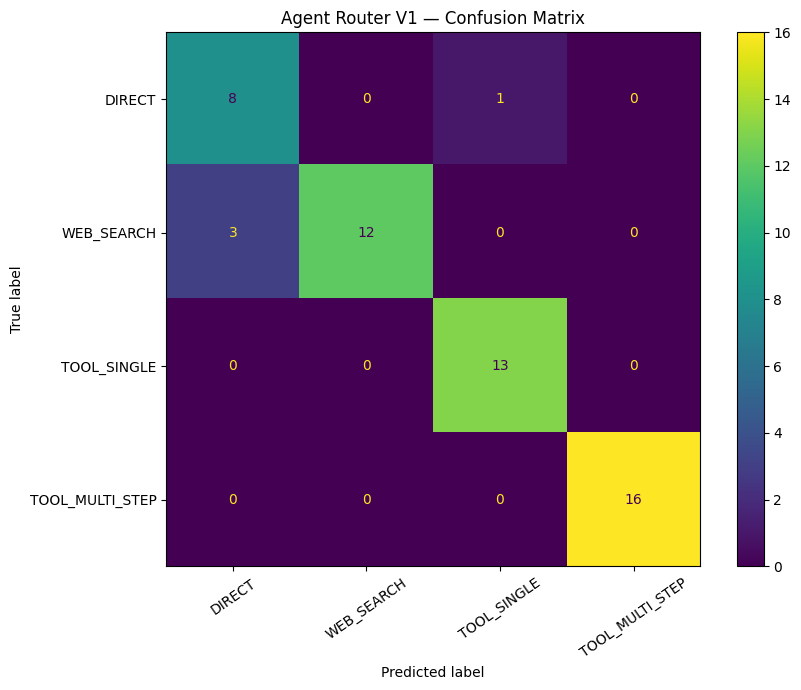


WRONG PREDICTIONS


,true_label,pred_label,text
11,WEB_SEARCH,DIRECT,Can you find a recipe for rendang?
23,WEB_SEARCH,DIRECT,What is the latest version of Python and when ...
28,DIRECT,TOOL_SINGLE,Define 'photosynthesis'.
43,WEB_SEARCH,DIRECT,what is the best way to learn Indonesian langu...



TOP CONFUSION PAIRS


,true_label,pred_label,count
1,WEB_SEARCH,DIRECT,3
0,DIRECT,TOOL_SINGLE,1


In [17]:
# =========================================================
# CELL 12 — CONFUSION + ERROR ANALYSIS
# AGENT ROUTER V1
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)


result_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "pred_label": agent_pred,
})

result_df["correct"] = (
    result_df["true_label"]
    == result_df["pred_label"]
)


# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    agent_pred,
    labels=AGENT_LABELS
)

fig, ax = plt.subplots(
    figsize=(9, 7)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=AGENT_LABELS
)

disp.plot(
    ax=ax,
    xticks_rotation=35,
    values_format="d"
)

plt.title(
    "Agent Router V1 — Confusion Matrix"
)

plt.tight_layout()
plt.show()


# =========================================================
# WRONG PREDICTIONS
# =========================================================

wrong_df = result_df[
    result_df["correct"] == False
].copy()


print()
print("=" * 70)
print("WRONG PREDICTIONS")
print("=" * 70)

display(
    wrong_df[
        [
            "true_label",
            "pred_label",
            "text",
        ]
    ]
)


# =========================================================
# CONFUSION PAIRS
# =========================================================

confusion_pairs = (
    wrong_df
    .groupby(
        [
            "true_label",
            "pred_label"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)


print()
print("=" * 70)
print("TOP CONFUSION PAIRS")
print("=" * 70)

display(
    confusion_pairs
)


PER-LABEL METRICS


,label,precision,recall,f1,support
0,DIRECT,0.727273,0.888889,0.800000,9
1,WEB_SEARCH,1.000000,0.800000,0.888889,15
2,TOOL_SINGLE,0.928571,1.000000,0.962963,13
3,TOOL_MULTI_STEP,1.000000,1.000000,1.000000,16


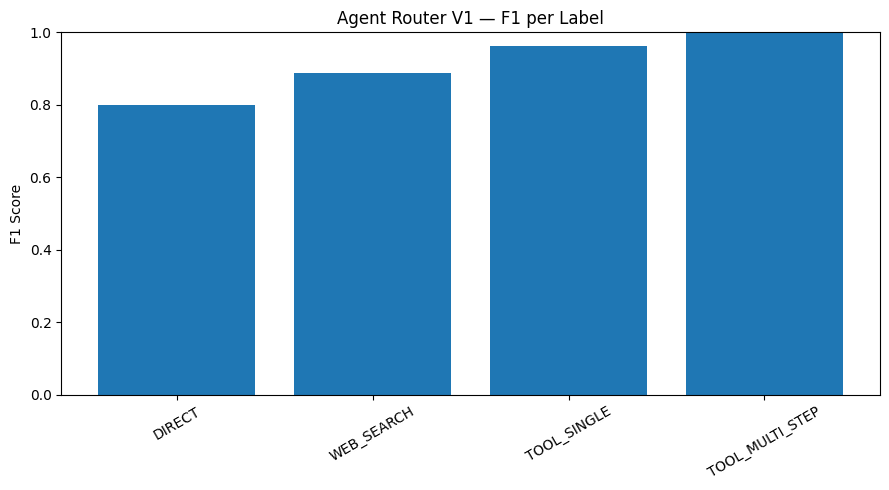

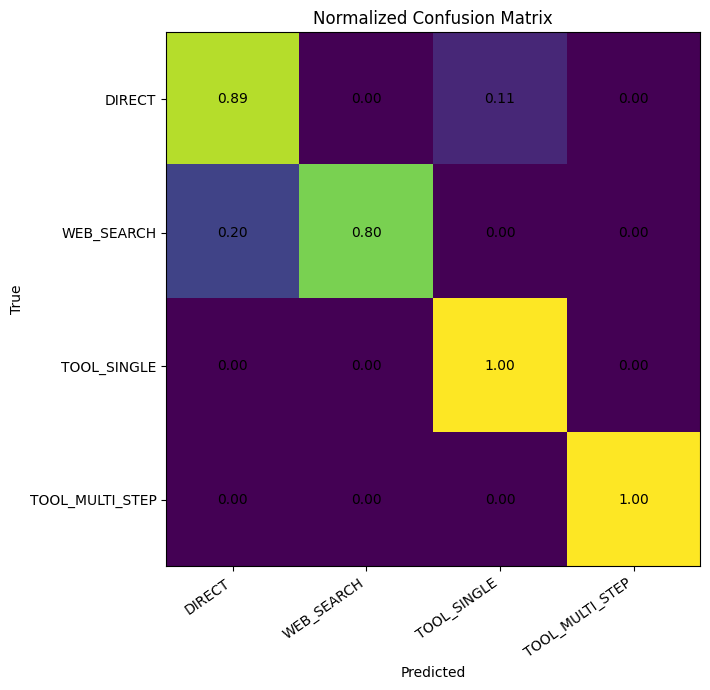


LOW-MARGIN / AMBIGUOUS PREDICTIONS


,true_label,pred_label,correct,margin,text
28,DIRECT,TOOL_SINGLE,False,0.080710,Define 'photosynthesis'.
33,TOOL_SINGLE,TOOL_SINGLE,True,0.094587,Send a text to Sarah: 'Can you pick up some co...
31,WEB_SEARCH,WEB_SEARCH,True,0.121520,What is the population of Indonesia in 2025?
43,WEB_SEARCH,DIRECT,False,0.137829,what is the best way to learn Indonesian langu...
11,WEB_SEARCH,DIRECT,False,0.175991,Can you find a recipe for rendang?
0,DIRECT,DIRECT,True,0.263769,What is the meaning of the idiom 'break the ice'?
8,WEB_SEARCH,WEB_SEARCH,True,0.358916,What is the latest update on the volcano erupt...
23,WEB_SEARCH,DIRECT,False,0.463857,What is the latest version of Python and when ...
34,TOOL_SINGLE,TOOL_SINGLE,True,0.506875,Start the robot vacuum in the living room.
26,WEB_SEARCH,WEB_SEARCH,True,0.659506,berapa kurs dollar ke rupiah hari ini?



HIGH-MARGIN WRONG PREDICTIONS


,true_label,pred_label,margin,text
23,WEB_SEARCH,DIRECT,0.463857,What is the latest version of Python and when ...
11,WEB_SEARCH,DIRECT,0.175991,Can you find a recipe for rendang?
43,WEB_SEARCH,DIRECT,0.137829,what is the best way to learn Indonesian langu...
28,DIRECT,TOOL_SINGLE,0.080710,Define 'photosynthesis'.


In [21]:
# =========================================================
# CELL 13 — ROUTER DIAGNOSTIC DASHBOARD
# AGENT ROUTER V1
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support,
)


# =========================================================
# 1. PER-LABEL METRICS
# =========================================================

precision, recall, f1, support = (
    precision_recall_fscore_support(
        y_test,
        agent_pred,
        labels=AGENT_LABELS,
        zero_division=0
    )
)

metric_df = pd.DataFrame({
    "label": AGENT_LABELS,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support,
})


print()
print("=" * 70)
print("PER-LABEL METRICS")
print("=" * 70)

display(metric_df)


# =========================================================
# 2. F1 BAR CHART
# =========================================================

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    metric_df["label"],
    metric_df["f1"]
)

plt.ylim(
    0,
    1
)

plt.ylabel(
    "F1 Score"
)

plt.title(
    "Agent Router V1 — F1 per Label"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()
plt.show()


# =========================================================
# 3. NORMALIZED CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    agent_pred,
    labels=AGENT_LABELS,
    normalize="true"
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

im = ax.imshow(
    cm
)

ax.set_xticks(
    range(len(AGENT_LABELS))
)

ax.set_yticks(
    range(len(AGENT_LABELS))
)

ax.set_xticklabels(
    AGENT_LABELS,
    rotation=35,
    ha="right"
)

ax.set_yticklabels(
    AGENT_LABELS
)

ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "True"
)

ax.set_title(
    "Normalized Confusion Matrix"
)


for i in range(
    len(AGENT_LABELS)
):

    for j in range(
        len(AGENT_LABELS)
    ):

        ax.text(
            j,
            i,
            f"{cm[i, j]:.2f}",
            ha="center",
            va="center"
        )


plt.tight_layout()
plt.show()


# =========================================================
# 4. DECISION MARGIN
# LinearSVC confidence proxy
# =========================================================

scores = agent_model.decision_function(
    X_test
)

sorted_scores = np.sort(
    scores,
    axis=1
)

top1 = sorted_scores[:, -1]
top2 = sorted_scores[:, -2]

margin = (
    top1
    - top2
)


diagnostic_df = result_df.copy()

diagnostic_df["margin"] = margin


# =========================================================
# 5. LOW MARGIN / AMBIGUOUS
# =========================================================

print()
print("=" * 70)
print("LOW-MARGIN / AMBIGUOUS PREDICTIONS")
print("=" * 70)

display(
    diagnostic_df
    .sort_values(
        "margin",
        ascending=True
    )
    [
        [
            "true_label",
            "pred_label",
            "correct",
            "margin",
            "text",
        ]
    ]
    .head(20)
)


# =========================================================
# 6. HIGH-CONFIDENCE WRONG
# =========================================================

print()
print("=" * 70)
print("HIGH-MARGIN WRONG PREDICTIONS")
print("=" * 70)

high_margin_wrong = (
    diagnostic_df[
        diagnostic_df["correct"] == False
    ]
    .sort_values(
        "margin",
        ascending=False
    )
)

display(
    high_margin_wrong[
        [
            "true_label",
            "pred_label",
            "margin",
            "text",
        ]
    ]
)

In [22]:
# =========================================================
# CELL 14 — BUILD AGENT ROUTER ERROR CONTEXT
# HARD-BOUNDARY REPAIR
# =========================================================

agent_error_context = []

for _, row in wrong_df.iterrows():

    agent_error_context.append(
        {
            "text": row["text"],
            "correct_label": row["true_label"],
            "wrong_prediction": row["pred_label"],
        }
    )


print()
print("=" * 70)
print("AGENT ROUTER ERROR CONTEXT")
print("=" * 70)

for item in agent_error_context:

    print()
    print("TEXT   :", item["text"])
    print("CORRECT:", item["correct_label"])
    print("WRONG  :", item["wrong_prediction"])

print()
print("=" * 70)


AGENT ROUTER ERROR CONTEXT

TEXT   : Can you find a recipe for rendang?
CORRECT: WEB_SEARCH
WRONG  : DIRECT

TEXT   : What is the latest version of Python and when was it released?
CORRECT: WEB_SEARCH
WRONG  : DIRECT

TEXT   : Define 'photosynthesis'.
CORRECT: DIRECT
WRONG  : TOOL_SINGLE

TEXT   : what is the best way to learn Indonesian language online?
CORRECT: WEB_SEARCH
WRONG  : DIRECT



In [23]:
# =========================================================
# CELL 15 — GENERATE HARD BOUNDARY DATA
# AGENT ROUTER V1
# =========================================================

import json
import requests
import pandas as pd


AGENT_BOUNDARY_GENERATOR_PROMPT = """
You generate HARD contrastive training examples for an
execution-routing classifier.

The classifier labels are:

DIRECT
WEB_SEARCH
TOOL_SINGLE
TOOL_MULTI_STEP

You will receive real classification errors.

Generate examples specifically designed to teach the
decision boundaries shown in those errors.

For each important confusion pair, generate examples for
BOTH sides of the boundary.

=========================================================
DIRECT
=========================================================

The request can be completed locally.

No current web information is required.
No external account/application/device action is required.

Examples:

"jelaskan apa itu ESP32"
"ringkas teks berikut: ..."
"buat function python sederhana"

=========================================================
WEB_SEARCH
=========================================================

Current or external public information must be retrieved
from the internet.

Retrieval only. No external write/action is required.

Examples:

"berapa harga emas hari ini"
"cari berita AI terbaru"
"berapa harga ESP32 sekarang"

=========================================================
TOOL_SINGLE
=========================================================

One primary external application/account/device action is
required.

Examples:

"cek email terakhir saya"
"buat event kalender besok"
"masukkan data ini ke spreadsheet"
"baca file report saya"

=========================================================
TOOL_MULTI_STEP
=========================================================

Multiple dependent external actions are required.

Examples:

"cari harga ESP32 lalu masukkan 10 termurah ke spreadsheet"

"cek email belum dibaca, rangkum, lalu kirim hasilnya"

=========================================================
IMPORTANT HARD BOUNDARIES
=========================================================

"jelaskan isi email berikut: [email text already supplied]"
-> DIRECT

"baca email terakhir saya dan jelaskan isinya"
-> TOOL_SINGLE


"apa harga rata-rata laptop gaming secara umum"
-> DIRECT

"berapa harga laptop gaming hari ini"
-> WEB_SEARCH


"ringkas file berikut: [content already supplied]"
-> DIRECT

"buka file report saya dan ringkas"
-> TOOL_SINGLE


"jelaskan berita tentang AI secara umum"
-> DIRECT

"cari berita AI terbaru hari ini"
-> WEB_SEARCH


"buat tabel dari data berikut"
-> DIRECT

"masukkan data berikut ke Google Sheets"
-> TOOL_SINGLE

=========================================================
OUTPUT
=========================================================

Do not answer the requests.

Use Indonesian and English.

Use realistic user wording:
- short prompts
- casual prompts
- typo-like prompts
- longer prompts

Avoid duplicates and near duplicates.

Return ONLY JSON:

{
  "items": [
    {
      "text": "...",
      "target_label": "DIRECT"
    }
  ]
}
"""


def generate_agent_boundary_examples(
    errors,
    count=80
):

    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json",
    }

    user_prompt = f"""
Current classifier errors:

{json.dumps(
    errors,
    ensure_ascii=False,
    indent=2
)}

Generate {count} hard contrastive user requests.

Focus especially on:

DIRECT vs WEB_SEARCH
DIRECT vs TOOL_SINGLE

Also include a smaller number of:
WEB_SEARCH vs TOOL_MULTI_STEP
TOOL_SINGLE vs TOOL_MULTI_STEP

Generate examples for BOTH sides of each boundary.
"""

    payload = {
        "model": MODEL,
        "temperature": 0.7,

        "thinking": {
            "type": "disabled"
        },

        "response_format": {
            "type": "json_object"
        },

        "messages": [
            {
                "role": "system",
                "content": AGENT_BOUNDARY_GENERATOR_PROMPT,
            },
            {
                "role": "user",
                "content": user_prompt,
            },
        ],
    }

    response = requests.post(
        BASE_URL,
        headers=headers,
        json=payload,
        timeout=(
            TIMEOUT_CONNECT,
            TIMEOUT_READ
        ),
    )

    response.raise_for_status()

    content = (
        response
        .json()["choices"][0]["message"]["content"]
    )

    data = json.loads(
        content
    )

    items = data.get(
        "items",
        []
    )

    if not isinstance(items, list):

        raise ValueError(
            "Generator output 'items' bukan list."
        )

    return items


# =========================================================
# GENERATE IN SMALL BATCHES
# =========================================================

all_boundary_items = []

BATCH_SIZE = 20
TOTAL_TARGET = 80


print()
print("=" * 70)
print("AGENT BOUNDARY GENERATION")
print("=" * 70)


for batch_idx in range(
    TOTAL_TARGET // BATCH_SIZE
):

    print(
        f"Batch {batch_idx + 1}/"
        f"{TOTAL_TARGET // BATCH_SIZE}"
    )

    try:

        items = generate_agent_boundary_examples(
            agent_error_context,
            count=BATCH_SIZE
        )

        print(
            "Received:",
            len(items)
        )

        all_boundary_items.extend(
            items
        )

    except Exception as e:

        print(
            "ERROR:",
            type(e).__name__,
            str(e)
        )


agent_boundary_df = pd.DataFrame(
    all_boundary_items
)


required_cols = {
    "text",
    "target_label"
}

if not required_cols.issubset(
    agent_boundary_df.columns
):

    raise ValueError(
        "Generator output tidak memiliki kolom yang diperlukan."
    )


agent_boundary_df = agent_boundary_df[
    agent_boundary_df["target_label"].isin(
        AGENT_LABELS
    )
].copy()


# =========================================================
# DEDUP
# =========================================================

agent_boundary_df["normalized_text"] = (
    agent_boundary_df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
)


existing_agent_text = set(
    agent_clean_df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
)


agent_boundary_df = (
    agent_boundary_df[
        ~agent_boundary_df[
            "normalized_text"
        ].isin(
            existing_agent_text
        )
    ]
    .drop_duplicates(
        subset=["normalized_text"]
    )
    .reset_index(drop=True)
)


print()
print("=" * 70)
print("BOUNDARY CANDIDATES")
print("=" * 70)

print(
    "Candidates:",
    len(agent_boundary_df)
)

print()

print(
    agent_boundary_df["target_label"]
    .value_counts()
    .reindex(
        AGENT_LABELS,
        fill_value=0
    )
)

display(
    agent_boundary_df.head(30)
)


AGENT BOUNDARY GENERATION
Batch 1/4
Received: 20
Batch 2/4
Received: 40
Batch 3/4
Received: 20
Batch 4/4
Received: 20

BOUNDARY CANDIDATES
Candidates: 99

target_label
DIRECT             31
WEB_SEARCH         33
TOOL_SINGLE        18
TOOL_MULTI_STEP    17
Name: count, dtype: int64


,text,target_label,normalized_text
0,How do you make nasi goreng?,DIRECT,how do you make nasi goreng?
1,Can you give me a recipe for rendang?,WEB_SEARCH,can you give me a recipe for rendang?
2,Explain the process of photosynthesis in simpl...,DIRECT,explain the process of photosynthesis in simpl...
3,What is photosynthesis?,DIRECT,what is photosynthesis?
4,Find the definition of photosynthesis online.,WEB_SEARCH,find the definition of photosynthesis online.
5,Latest Python version and release date?,WEB_SEARCH,latest python version and release date?
6,What are some effective methods to learn Indon...,DIRECT,what are some effective methods to learn indon...
7,Search for the best online courses to learn In...,WEB_SEARCH,search for the best online courses to learn in...
8,What's the capital of France?,DIRECT,what's the capital of france?
9,What is the current population of France?,WEB_SEARCH,what is the current population of france?


In [24]:
# =========================================================
# CELL 16 — AUDIT AGENT HARD BOUNDARY DATA
# AGENT ROUTER V1
# =========================================================

MIN_BOUNDARY_CONFIDENCE = 0.90

agent_boundary_audit_rows = []

total = len(
    agent_boundary_df
)


print()
print("=" * 70)
print("AGENT BOUNDARY TEACHER AUDIT")
print("=" * 70)


for idx, row in agent_boundary_df.iterrows():

    text = row["text"]
    target = row["target_label"]

    print(
        f"[{idx + 1}/{total}] "
        f"{target}"
    )

    try:

        raw, latency = call_agent_teacher(
            text
        )

        result = parse_agent_teacher(
            raw
        )

        accepted = (
            result["label"] == target
            and
            result["confidence"]
            >= MIN_BOUNDARY_CONFIDENCE
        )


        agent_boundary_audit_rows.append(
            {
                "text": text,
                "target_label": target,
                "teacher_label": result["label"],
                "confidence": result["confidence"],
                "latency": latency,
                "accepted": accepted,
            }
        )


        print(
            "   ->",
            result["label"],
            f"{result['confidence']:.2f}",
            "ACCEPT"
            if accepted
            else "REJECT"
        )


    except Exception as e:

        agent_boundary_audit_rows.append(
            {
                "text": text,
                "target_label": target,
                "teacher_label": None,
                "confidence": None,
                "latency": None,
                "accepted": False,
                "error": str(e),
            }
        )

        print(
            "   -> ERROR:",
            type(e).__name__,
            str(e)
        )


agent_boundary_audit_df = pd.DataFrame(
    agent_boundary_audit_rows
)


print()
print("=" * 70)
print("AGENT BOUNDARY AUDIT SUMMARY")
print("=" * 70)

boundary_summary = (
    agent_boundary_audit_df
    .groupby(
        "target_label"
    )
    .agg(
        generated=("text", "count"),
        accepted=("accepted", "sum"),
        avg_confidence=("confidence", "mean"),
    )
)

display(
    boundary_summary
)


AGENT BOUNDARY TEACHER AUDIT
[1/99] DIRECT
   -> DIRECT 0.95 ACCEPT
[2/99] WEB_SEARCH
   -> DIRECT 0.98 REJECT
[3/99] DIRECT
   -> DIRECT 0.98 ACCEPT
[4/99] DIRECT
   -> DIRECT 0.98 ACCEPT
[5/99] WEB_SEARCH
   -> WEB_SEARCH 1.00 ACCEPT
[6/99] WEB_SEARCH
   -> WEB_SEARCH 1.00 ACCEPT
[7/99] DIRECT
   -> DIRECT 0.95 ACCEPT
[8/99] WEB_SEARCH
   -> WEB_SEARCH 0.95 ACCEPT
[9/99] DIRECT
   -> DIRECT 1.00 ACCEPT
[10/99] WEB_SEARCH
   -> WEB_SEARCH 1.00 ACCEPT
[11/99] DIRECT
   -> DIRECT 0.95 ACCEPT
[12/99] TOOL_SINGLE
   -> TOOL_SINGLE 1.00 ACCEPT
[13/99] TOOL_SINGLE
   -> DIRECT 0.95 REJECT
[14/99] DIRECT
   -> DIRECT 1.00 ACCEPT
[15/99] TOOL_SINGLE
   -> TOOL_SINGLE 1.00 ACCEPT
[16/99] TOOL_MULTI_STEP
   -> TOOL_MULTI_STEP 1.00 ACCEPT
[17/99] TOOL_MULTI_STEP
   -> TOOL_MULTI_STEP 0.95 ACCEPT
[18/99] WEB_SEARCH
   -> WEB_SEARCH 0.95 ACCEPT
[19/99] TOOL_SINGLE
   -> TOOL_MULTI_STEP 0.90 REJECT
[20/99] TOOL_MULTI_STEP
   -> TOOL_MULTI_STEP 0.95 ACCEPT
[21/99] WEB_SEARCH
   -> DIRECT 0.98 REJEC

,generated,accepted,avg_confidence
target_label,,,
DIRECT,31,30,0.970323
TOOL_MULTI_STEP,17,17,0.976471
TOOL_SINGLE,18,16,0.975000
WEB_SEARCH,33,30,0.976364


In [25]:
# =========================================================
# CELL 17 — BUILD ACCEPTED BOUNDARY DATASET
# AGENT ROUTER V1
# =========================================================

AGENT_BOUNDARY_ACCEPTED_PATH = (
    f"{AGENT_DIR}/agent_router_v1_boundary_accepted.csv"
)

AGENT_BOUNDARY_AUDIT_PATH = (
    f"{AGENT_DIR}/agent_router_v1_boundary_audit.csv"
)


agent_boundary_accepted_df = (
    agent_boundary_audit_df[
        agent_boundary_audit_df["accepted"] == True
    ]
    .copy()
)


agent_boundary_accepted_df = (
    agent_boundary_accepted_df[
        [
            "text",
            "teacher_label",
            "confidence",
        ]
    ]
    .rename(
        columns={
            "teacher_label": "label"
        }
    )
)


# =========================================================
# DEDUP
# =========================================================

agent_boundary_accepted_df["normalized_text"] = (
    agent_boundary_accepted_df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
)

agent_boundary_accepted_df = (
    agent_boundary_accepted_df
    .drop_duplicates(
        subset=["normalized_text"]
    )
    .drop(
        columns=["normalized_text"]
    )
    .reset_index(drop=True)
)


# =========================================================
# SAVE
# =========================================================

agent_boundary_accepted_df.to_csv(
    AGENT_BOUNDARY_ACCEPTED_PATH,
    index=False
)

agent_boundary_audit_df.to_csv(
    AGENT_BOUNDARY_AUDIT_PATH,
    index=False
)


print()
print("=" * 70)
print("AGENT BOUNDARY ACCEPTED DATASET")
print("=" * 70)

print(
    "Accepted:",
    len(agent_boundary_accepted_df)
)

print()

print(
    agent_boundary_accepted_df["label"]
    .value_counts()
    .reindex(
        AGENT_LABELS,
        fill_value=0
    )
)

print("=" * 70)


AGENT BOUNDARY ACCEPTED DATASET
Accepted: 93

label
DIRECT             30
WEB_SEARCH         30
TOOL_SINGLE        16
TOOL_MULTI_STEP    17
Name: count, dtype: int64


In [26]:
# =========================================================
# CELL 18 — BUILD REPAIRED AGENT TRAIN SET
# IMPORTANT: FROZEN TEST SET TETAP SAMA
# =========================================================

import pandas as pd


# Dataset train baseline saja.
# Jangan masukkan X_test/y_test ke training.
base_agent_train_df = pd.DataFrame({
    "text": X_train.values,
    "label": y_train.values,
})


agent_repaired_train_df = pd.concat(
    [
        base_agent_train_df,

        agent_boundary_accepted_df[
            [
                "text",
                "label"
            ]
        ],
    ],
    ignore_index=True
)


# =========================================================
# NORMALIZE + DEDUP
# =========================================================

agent_repaired_train_df["normalized_text"] = (
    agent_repaired_train_df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
)

agent_repaired_train_df = (
    agent_repaired_train_df
    .drop_duplicates(
        subset=["normalized_text"],
        keep="first"
    )
    .drop(
        columns=["normalized_text"]
    )
    .reset_index(drop=True)
)


print()
print("=" * 70)
print("REPAIRED AGENT TRAIN DATASET")
print("=" * 70)

print(
    "Original train :",
    len(base_agent_train_df)
)

print(
    "Boundary added :",
    len(agent_boundary_accepted_df)
)

print(
    "Final train    :",
    len(agent_repaired_train_df)
)

print()

print(
    agent_repaired_train_df["label"]
    .value_counts()
    .reindex(
        AGENT_LABELS,
        fill_value=0
    )
)

print("=" * 70)


REPAIRED AGENT TRAIN DATASET
Original train : 211
Boundary added : 93
Final train    : 304

label
DIRECT             68
WEB_SEARCH         88
TOOL_SINGLE        68
TOOL_MULTI_STEP    80
Name: count, dtype: int64


In [27]:
# =========================================================
# CELL 19 — RETRAIN + EVALUATE BOUNDARY REPAIR
# AGENT ROUTER V1
# =========================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
)


agent_repaired_model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=1,
                max_df=0.98,
                max_features=20000,
                sublinear_tf=True,
            )
        ),

        (
            "classifier",
            LinearSVC(
                C=1.0,
                class_weight="balanced",
                random_state=42,
            )
        ),
    ]
)


# =========================================================
# TRAIN
# =========================================================

agent_repaired_model.fit(
    agent_repaired_train_df["text"],
    agent_repaired_train_df["label"]
)


# =========================================================
# SAME FROZEN HOLDOUT
# =========================================================

agent_repaired_pred = agent_repaired_model.predict(
    X_test
)


agent_repaired_accuracy = accuracy_score(
    y_test,
    agent_repaired_pred
)

agent_repaired_macro_f1 = f1_score(
    y_test,
    agent_repaired_pred,
    average="macro",
    zero_division=0
)

agent_repaired_weighted_f1 = f1_score(
    y_test,
    agent_repaired_pred,
    average="weighted",
    zero_division=0
)


print()
print("=" * 70)
print("AGENT ROUTER — AFTER BOUNDARY REPAIR")
print("=" * 70)

print(
    f"Accuracy    : {agent_repaired_accuracy:.4f}"
)

print(
    f"Macro F1    : {agent_repaired_macro_f1:.4f}"
)

print(
    f"Weighted F1 : {agent_repaired_weighted_f1:.4f}"
)

print()

print(
    classification_report(
        y_test,
        agent_repaired_pred,
        labels=AGENT_LABELS,
        digits=4,
        zero_division=0
    )
)


# =========================================================
# BEFORE VS AFTER
# =========================================================

print()
print("=" * 70)
print("BASELINE VS REPAIRED")
print("=" * 70)

print()
print("BASELINE")
print(
    f"Accuracy    : {agent_accuracy:.4f}"
)
print(
    f"Macro F1    : {agent_macro_f1:.4f}"
)
print(
    f"Weighted F1 : {agent_weighted_f1:.4f}"
)

print()
print("REPAIRED")
print(
    f"Accuracy    : {agent_repaired_accuracy:.4f}"
)
print(
    f"Macro F1    : {agent_repaired_macro_f1:.4f}"
)
print(
    f"Weighted F1 : {agent_repaired_weighted_f1:.4f}"
)

print()
print(
    "Macro F1 gain:",
    f"{agent_repaired_macro_f1 - agent_macro_f1:+.4f}"
)


AGENT ROUTER — AFTER BOUNDARY REPAIR
Accuracy    : 0.9811
Macro F1    : 0.9768
Weighted F1 : 0.9813

                 precision    recall  f1-score   support

         DIRECT     0.9000    1.0000    0.9474         9
     WEB_SEARCH     1.0000    1.0000    1.0000        15
    TOOL_SINGLE     1.0000    0.9231    0.9600        13
TOOL_MULTI_STEP     1.0000    1.0000    1.0000        16

       accuracy                         0.9811        53
      macro avg     0.9750    0.9808    0.9768        53
   weighted avg     0.9830    0.9811    0.9813        53


BASELINE VS REPAIRED

BASELINE
Accuracy    : 0.9245
Macro F1    : 0.9130
Weighted F1 : 0.9255

REPAIRED
Accuracy    : 0.9811
Macro F1    : 0.9768
Weighted F1 : 0.9813

Macro F1 gain: +0.0639


In [28]:
# =========================================================
# CELL 20 — EXPORT AGENT ROUTER V1 TO ONNX
# =========================================================

!pip -q install skl2onnx onnx onnxruntime

import os

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import StringTensorType


AGENT_ONNX_PATH = (
    f"{AGENT_DIR}/agent_router_v1.onnx"
)


initial_types = [
    (
        "input",
        StringTensorType(
            [None, 1]
        )
    )
]


onnx_model = convert_sklearn(
    agent_repaired_model,
    initial_types=initial_types,
    target_opset=17,

    options={
        id(
            agent_repaired_model.named_steps[
                "classifier"
            ]
        ): {
            "raw_scores": True
        }
    }
)


with open(
    AGENT_ONNX_PATH,
    "wb"
) as f:

    f.write(
        onnx_model.SerializeToString()
    )


size_mb = (
    os.path.getsize(AGENT_ONNX_PATH)
    / 1024
    / 1024
)


print()
print("=" * 70)
print("AGENT ROUTER ONNX EXPORT")
print("=" * 70)

print(
    "Saved:",
    AGENT_ONNX_PATH
)

print(
    f"Size : {size_mb:.3f} MB"
)

print("=" * 70)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 46.0 MB/s eta 0:00:00

AGENT ROUTER ONNX EXPORT
Saved: /content/drive/MyDrive/router_classifier/agent_router_v1/agent_router_v1.onnx
Size : 0.114 MB


In [29]:
# =========================================================
# CELL 21 — AGENT ROUTER ONNX PARITY TEST
# =========================================================

import onnx
import onnxruntime as ort
import numpy as np


# =========================================================
# CHECK MODEL
# =========================================================

agent_onnx_model = onnx.load(
    AGENT_ONNX_PATH
)

onnx.checker.check_model(
    agent_onnx_model
)

print(
    "ONNX checker: PASS"
)


# =========================================================
# SESSION
# =========================================================

agent_session = ort.InferenceSession(
    AGENT_ONNX_PATH,
    providers=[
        "CPUExecutionProvider"
    ]
)

agent_input_name = (
    agent_session
    .get_inputs()[0]
    .name
)


# =========================================================
# TEST PROMPTS
# =========================================================

AGENT_TEST_PROMPTS = [
    "jelaskan fungsi esp32 c6",

    "berapa harga emas hari ini",

    "cek email terakhir saya",

    "cari 10 esp32 termurah lalu masukkan ke google sheet",

    "buat cerita tentang robot kecil",

    "cari berita ai terbaru",

    "buat event kalender besok jam 10",

    "cek email belum dibaca lalu rangkum dan kirim hasilnya",
]


# =========================================================
# SKLEARN
# =========================================================

sklearn_pred = agent_repaired_model.predict(
    AGENT_TEST_PROMPTS
)


# =========================================================
# ONNX
# =========================================================

onnx_input = np.array(
    AGENT_TEST_PROMPTS,
    dtype=object
).reshape(
    -1,
    1
)

outputs = agent_session.run(
    None,
    {
        agent_input_name: onnx_input
    }
)

onnx_pred = np.array(
    outputs[0]
).reshape(-1)


# =========================================================
# COMPARE
# =========================================================

print()
print("=" * 70)
print("AGENT ROUTER — JOBLIB VS ONNX")
print("=" * 70)

matches = []

for prompt, jp, op in zip(
    AGENT_TEST_PROMPTS,
    sklearn_pred,
    onnx_pred
):

    match = (
        str(jp)
        == str(op)
    )

    matches.append(match)

    print()
    print(
        "Prompt :",
        prompt
    )

    print(
        "Joblib :",
        jp
    )

    print(
        "ONNX   :",
        op
    )

    print(
        "Match  :",
        match
    )


print()
print("=" * 70)

print(
    "Parity:",
    sum(matches),
    "/",
    len(matches)
)

print("=" * 70)

ONNX checker: PASS

AGENT ROUTER — JOBLIB VS ONNX

Prompt : jelaskan fungsi esp32 c6
Joblib : DIRECT
ONNX   : DIRECT
Match  : True

Prompt : berapa harga emas hari ini
Joblib : WEB_SEARCH
ONNX   : WEB_SEARCH
Match  : True

Prompt : cek email terakhir saya
Joblib : TOOL_MULTI_STEP
ONNX   : TOOL_MULTI_STEP
Match  : True

Prompt : cari 10 esp32 termurah lalu masukkan ke google sheet
Joblib : TOOL_MULTI_STEP
ONNX   : TOOL_MULTI_STEP
Match  : True

Prompt : buat cerita tentang robot kecil
Joblib : TOOL_MULTI_STEP
ONNX   : TOOL_MULTI_STEP
Match  : True

Prompt : cari berita ai terbaru
Joblib : TOOL_MULTI_STEP
ONNX   : TOOL_MULTI_STEP
Match  : True

Prompt : buat event kalender besok jam 10
Joblib : TOOL_MULTI_STEP
ONNX   : TOOL_MULTI_STEP
Match  : True

Prompt : cek email belum dibaca lalu rangkum dan kirim hasilnya
Joblib : TOOL_MULTI_STEP
ONNX   : TOOL_MULTI_STEP
Match  : True

Parity: 8 / 8


In [30]:
# =========================================================
# COMBINED ONNX ROUTER TEST
# INTENT ROUTER + AGENT ROUTER
# =========================================================

import os
import numpy as np
import onnxruntime as ort


# =========================================================
# PATHS
# =========================================================

INTENT_ONNX_PATH = (
    f"{SAVE_DIR}/router_v2_production.onnx"
)

AGENT_ONNX_PATH = (
    f"{AGENT_DIR}/agent_router_v1.onnx"
)


# =========================================================
# FILE CHECK
# =========================================================

print()
print("=" * 70)
print("ONNX FILE CHECK")
print("=" * 70)

print(
    "Intent model exists:",
    os.path.exists(INTENT_ONNX_PATH)
)

print(
    "Agent model exists :",
    os.path.exists(AGENT_ONNX_PATH)
)

if not os.path.exists(INTENT_ONNX_PATH):

    raise FileNotFoundError(
        INTENT_ONNX_PATH
    )

if not os.path.exists(AGENT_ONNX_PATH):

    raise FileNotFoundError(
        AGENT_ONNX_PATH
    )

print(
    "Intent size:",
    round(
        os.path.getsize(INTENT_ONNX_PATH)
        / 1024
        / 1024,
        3
    ),
    "MB"
)

print(
    "Agent size :",
    round(
        os.path.getsize(AGENT_ONNX_PATH)
        / 1024
        / 1024,
        3
    ),
    "MB"
)

print("=" * 70)


# =========================================================
# LOAD BOTH MODELS
# =========================================================

intent_session = ort.InferenceSession(
    INTENT_ONNX_PATH,
    providers=[
        "CPUExecutionProvider"
    ]
)

agent_session = ort.InferenceSession(
    AGENT_ONNX_PATH,
    providers=[
        "CPUExecutionProvider"
    ]
)


intent_input_name = (
    intent_session
    .get_inputs()[0]
    .name
)

agent_input_name = (
    agent_session
    .get_inputs()[0]
    .name
)


print()
print("=" * 70)
print("ONNX LOAD")
print("=" * 70)

print(
    "Intent router : OK"
)

print(
    "Agent router  : OK"
)

print("=" * 70)


# =========================================================
# COMBINED ROUTER FUNCTION
# =========================================================

def route_combined(prompt):

    prompt = str(
        prompt
    ).strip()

    if not prompt:

        raise ValueError(
            "Prompt kosong."
        )

    x = np.array(
        [[prompt]],
        dtype=object
    )


    # INTENT
    intent_outputs = intent_session.run(
        None,
        {
            intent_input_name: x
        }
    )

    intent = str(
        np.array(
            intent_outputs[0]
        ).reshape(-1)[0]
    )


    # EXECUTION
    agent_outputs = agent_session.run(
        None,
        {
            agent_input_name: x
        }
    )

    execution = str(
        np.array(
            agent_outputs[0]
        ).reshape(-1)[0]
    )


    return {
        "intent": intent,
        "execution": execution,
    }


# =========================================================
# TEST CASES
# =========================================================

TEST_PROMPTS = [

    "Berapa harga emas hari ini",

    "Cari di marketplace Indonesia harga ESP32 lalu "
    "masukkan 10 termurah ke Google Sheet",

    "Jelaskan cara kerja DNS",

    "Bandingkan ESP32 C5 dan C6 untuk device low power",

    "Perbaiki syntax SQL saya yang error near created_at",

    "Debug service systemd saya yang restart terus",

    "Terjemahkan teks ini ke bahasa Inggris",

    "Buat nama untuk robot assistant kecil",

    "Cek email terakhir saya",

    "Cek email belum dibaca, rangkum yang penting, "
    "lalu kirim hasilnya",
]


print()
print("=" * 70)
print("COMBINED ROUTER TEST")
print("=" * 70)


for prompt in TEST_PROMPTS:

    result = route_combined(
        prompt
    )

    print()
    print(
        "PROMPT    :",
        prompt
    )

    print(
        "INTENT    :",
        result["intent"]
    )

    print(
        "EXECUTION :",
        result["execution"]
    )

    print(
        "-" * 70
    )


ONNX FILE CHECK
Intent model exists: True
Agent model exists : True
Intent size: 0.404 MB
Agent size : 0.114 MB

ONNX LOAD
Intent router : OK
Agent router  : OK

COMBINED ROUTER TEST

PROMPT    : Berapa harga emas hari ini
INTENT    : SIMPLE
EXECUTION : WEB_SEARCH
----------------------------------------------------------------------

PROMPT    : Cari di marketplace Indonesia harga ESP32 lalu masukkan 10 termurah ke Google Sheet
INTENT    : SIMPLE
EXECUTION : TOOL_MULTI_STEP
----------------------------------------------------------------------

PROMPT    : Jelaskan cara kerja DNS
INTENT    : GENERAL
EXECUTION : WEB_SEARCH
----------------------------------------------------------------------

PROMPT    : Bandingkan ESP32 C5 dan C6 untuk device low power
INTENT    : REASONING
EXECUTION : TOOL_MULTI_STEP
----------------------------------------------------------------------

PROMPT    : Perbaiki syntax SQL saya yang error near created_at
INTENT    : CODING_SIMPLE
EXECUTION : TOOL_MULTI